<a href="https://colab.research.google.com/github/noor-gh06/Cybercrime-DataMining/blob/main/Copy_of_phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cybercrime Data Mining Project - phase 3

1. Problem

This project aims to analyze cybercrime incidents and apply data mining techniques to better understand patterns in the data.

The goal is to predict the attack outcome using classification and discover hidden groupings among records using clustering. This problem is important because cybercrime is a growing issue, and data analysis can help in understanding attack behavior and improving response strategies.


2. Data Mining Task

This project includes two data mining tasks:

1. **Classification**: to predict the target class `outcome` based on the other attributes in the dataset.
2. **Clustering**: to group similar records together and discover hidden structures in the data without using the class label.

3. Data

The dataset used in this project is the Cyber Crimes Dataset. It contains 100,000 records and 15 attributes describing cybercrime incidents.

The dataset includes both categorical and numerical features, such as attack type, target system, timestamp, attack duration, attack severity, response time, and compromised data size.

The target variable used for classification is **outcome**.

The dataset is well-structured and suitable for both classification and clustering tasks.

4. Data Preprocessing

The dataset was preprocessed in Phase 2 before building the models.

The following preprocessing steps were applied:
- The timestamp attribute was converted into year, month, and hour features.
- High-cardinality attributes (`attacker_ip` and `target_ip`) were removed.
- Categorical variables were transformed using One-Hot Encoding.
- Missing values were handled appropriately.
- Numerical features were standardized to support clustering analysis.

These preprocessing steps improved the dataset quality and prepared it for the data mining phase.

5. Data Mining Technique

Two data mining techniques were applied in this phase:

##Decision Tree Classification
Decision Tree was used as the classification technique. Two attribute selection measures were tested:
- Gini Index
- Entropy

Each model was evaluated using three training/testing splits:
- 90% training / 10% testing
- 80% training / 20% testing
- 70% training / 30% testing

The models were trained using the Decision Tree algorithm with both Gini Index and Entropy criteria.

The performance was evaluated using:
- Accuracy
- Confusion Matrix
- Decision Tree Visualization

### K-Means Clustering
K-Means clustering was used to group similar records in the dataset. Three values of K were tested:
- K = 2
- K = 3
- K = 4

The clustering results were evaluated using:
- WCSS
- Elbow Method
- Silhouette Score
- Cluster Visualization

In [6]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_phase3 = pd.read_csv("final_dataset.csv")
df_phase3.head()

,outcome,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour,attack_type_Brute Force,attack_type_Cross-Site Scripting,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Technology,mitigation_method_Block IP,mitigation_method_Containment,mitigation_method_Patch,mitigation_method_Quarantine,mitigation_method_Reset Credentials
0,Failure,-1.205448,1.717105,-1.219286,1.416923,2024,4,11,False,False,...,False,False,False,False,False,False,True,False,False,False
1,Success,0.519862,1.048385,1.568458,-0.509669,2024,2,20,False,False,...,False,False,False,True,False,False,False,False,False,True
2,Success,-0.037204,-0.358233,0.523054,-0.066553,2024,7,18,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Failure,-1.171455,1.555690,-0.870818,-1.299572,2023,12,0,False,False,...,False,True,False,False,False,False,False,True,False,False
4,Failure,1.304125,-1.695674,0.174586,0.742616,2024,7,5,False,False,...,False,False,False,False,False,False,True,False,False,False


In [8]:
print("Shape of final dataset:", df_phase3.shape)
print("\nColumns:")
print(df_phase3.columns.tolist())

Shape of final dataset: (100000, 59)

Columns:
['outcome', 'data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min', 'year', 'month', 'hour', 'attack_type_Brute Force', 'attack_type_Cross-Site Scripting', 'attack_type_DDoS', 'attack_type_Malware', 'attack_type_Phishing', 'attack_type_Ransomware', 'attack_type_SQL Injection', 'attack_type_Zero-Day Exploit', 'target_system_API', 'target_system_Cloud Service', 'target_system_Database', 'target_system_Email Server', 'target_system_IoT Device', 'target_system_Network Switch', 'target_system_User Account', 'target_system_Web Server', 'security_tools_used_Antivirus', 'security_tools_used_Endpoint Detection', 'security_tools_used_Firewall', 'security_tools_used_IDS', 'security_tools_used_MFA', 'security_tools_used_SIEM', 'security_tools_used_VPN', 'security_tools_used_WAF', 'user_role_Admin', 'user_role_Contractor', 'user_role_Employee', 'user_role_External User', 'location_Australia', 'location_Brazil', 'location_C

In [9]:
X = df_phase3.drop("outcome", axis=1)
y = df_phase3["outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (100000, 58)
y shape: (100000,)

Class distribution:
outcome
Success    50030
Failure    49970
Name: count, dtype: int64


The feature variables and target class (outcome) are defined

In [10]:
X_clustering = df_phase3.drop("outcome", axis=1)

print("Clustering data shape:", X_clustering.shape)

Clustering data shape: (100000, 58)


Then, the dataset is split into three training/testing partitions: 90/10, 80/20, and 70/30

In [11]:
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("90/10 split:")
print("X_train_90:", X_train_90.shape)
print("X_test_10 :", X_test_10.shape)
print("y_train_90:", y_train_90.shape)
print("y_test_10 :", y_test_10.shape)

90/10 split:
X_train_90: (90000, 58)
X_test_10 : (10000, 58)
y_train_90: (90000,)
y_test_10 : (10000,)


In [12]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("80/20 split:")
print("X_train_80:", X_train_80.shape)
print("X_test_20 :", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20 :", y_test_20.shape)

80/20 split:
X_train_80: (80000, 58)
X_test_20 : (20000, 58)
y_train_80: (80000,)
y_test_20 : (20000,)


In [13]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("70/30 split:")
print("X_train_70:", X_train_70.shape)
print("X_test_30 :", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30 :", y_test_30.shape)

70/30 split:
X_train_70: (70000, 58)
X_test_30 : (30000, 58)
y_train_70: (70000,)
y_test_30 : (30000,)


In [14]:
#Import Libraries
#Loads machine learning tools
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [15]:
#Model Training (90/10 Split)
#Trains Decision Tree using Gini on 90/10 split
model_90 = DecisionTreeClassifier(criterion='gini')
model_90.fit(X_train_90, y_train_90)

DecisionTreeClassifier()

In [16]:
#Prediction (90/10)
y_pred_90 = model_90.predict(X_test_10)

In [17]:
#Accuracy (90/10)
acc_90 = accuracy_score(y_test_10, y_pred_90)
print("Accuracy (90/10):", acc_90)

Accuracy (90/10): 0.5039


In [18]:
#Confusion Matrix (90/10)
cm_90 = confusion_matrix(y_test_10, y_pred_90)
print("Confusion Matrix (90/10):\n", cm_90)

Confusion Matrix (90/10):
 [[2522 2475]
 [2486 2517]]


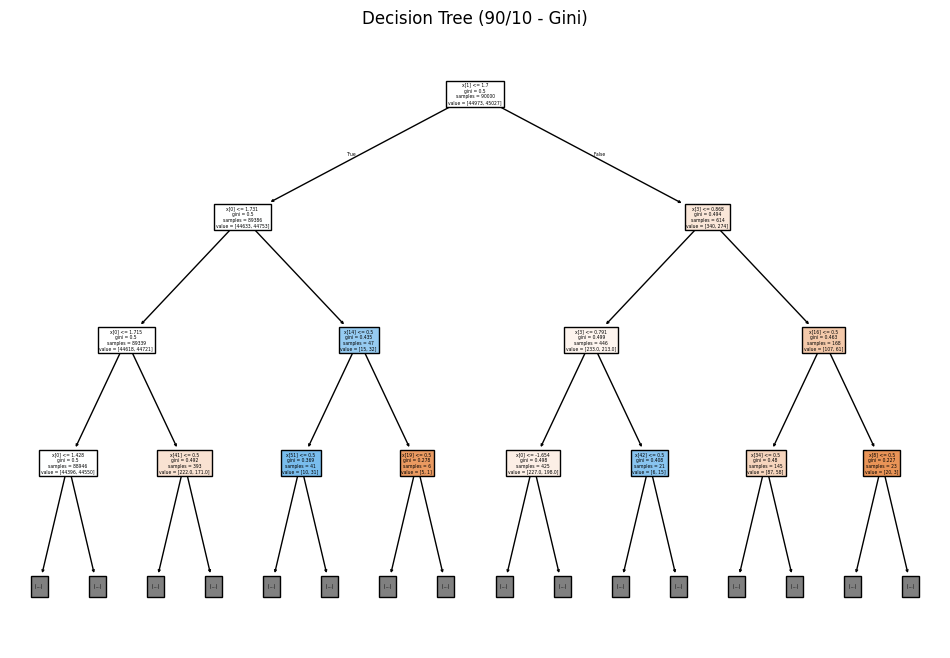

In [19]:
#Decision Tree Visualization (90/10)
plt.figure(figsize=(12,8))
plot_tree(model_90, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Gini)")
plt.show()

Accuracy (80/20): 0.4993
Confusion Matrix (80/20):
 [[4945 5049]
 [4965 5041]]


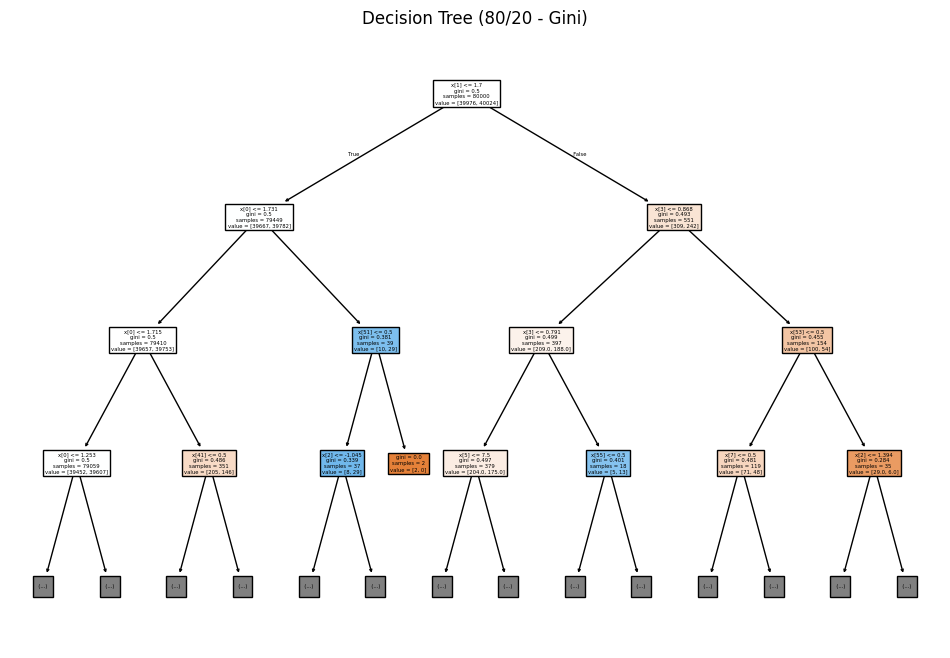

In [20]:
#(80/20)
model_80 = DecisionTreeClassifier(criterion='gini')
model_80.fit(X_train_80, y_train_80)

y_pred_80 = model_80.predict(X_test_20)

acc_80 = accuracy_score(y_test_20, y_pred_80)
print("Accuracy (80/20):", acc_80)

cm_80 = confusion_matrix(y_test_20, y_pred_80)
print("Confusion Matrix (80/20):\n", cm_80)

plt.figure(figsize=(12,8))
plot_tree(model_80, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Gini)")
plt.show()

Accuracy (70/30): 0.49743333333333334
Confusion Matrix (70/30):
 [[7488 7503]
 [7574 7435]]


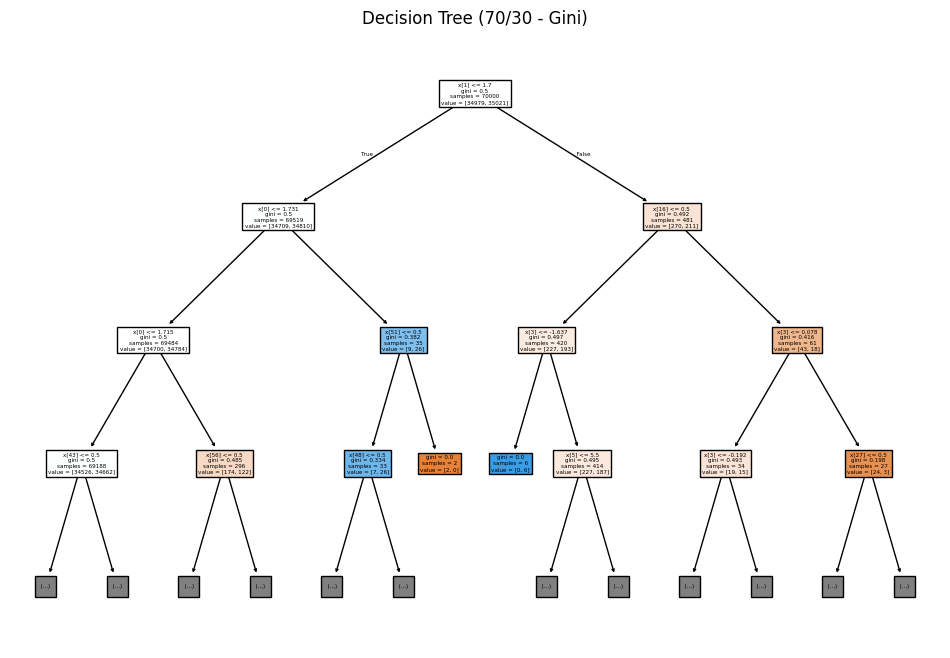

In [21]:
#(70/30)
model_70 = DecisionTreeClassifier(criterion='gini')
model_70.fit(X_train_70, y_train_70)

y_pred_70 = model_70.predict(X_test_30)

acc_70 = accuracy_score(y_test_30, y_pred_70)
print("Accuracy (70/30):", acc_70)

cm_70 = confusion_matrix(y_test_30, y_pred_70)
print("Confusion Matrix (70/30):\n", cm_70)

plt.figure(figsize=(12,8))
plot_tree(model_70, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Gini)")
plt.show()

**Conclusion**

The Decision Tree model using Gini criterion was applied on three different data splits. The 90/10 split achieved the highest accuracy, likely due to having more training data. The model performed consistently across all splits, indicating stable performance.

In [22]:
# Decision Tree using Entropy

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

Accuracy (90/10 - Entropy): 0.506
Confusion Matrix (90/10 - Entropy):
 [[2530 2467]
 [2473 2530]]


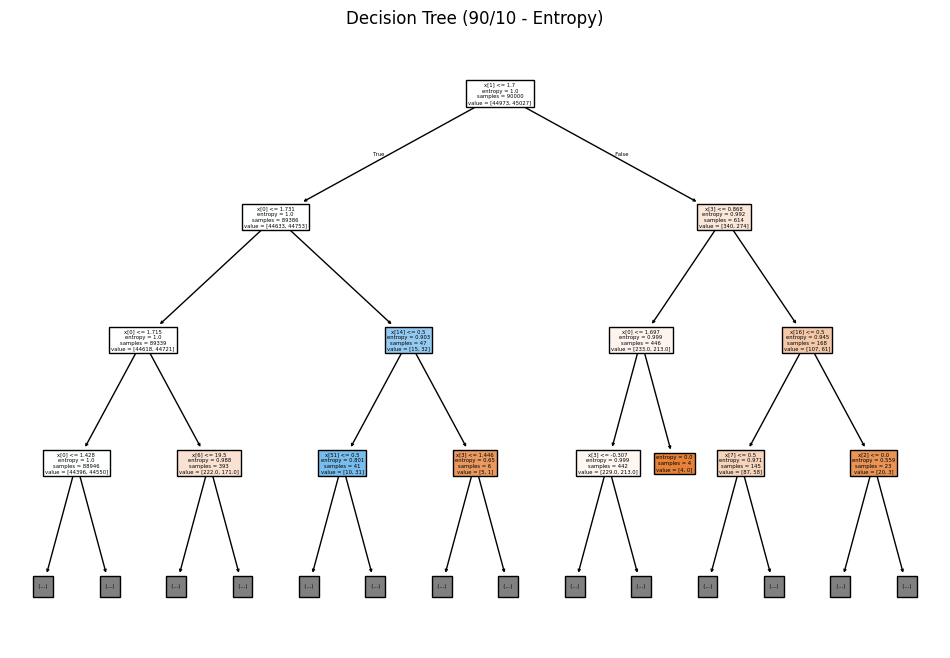

In [23]:
# (90/10) Split - Entropy

model_90_e = DecisionTreeClassifier(criterion='entropy')
model_90_e.fit(X_train_90, y_train_90)

y_pred_90_e = model_90_e.predict(X_test_10)

acc_90_e = accuracy_score(y_test_10, y_pred_90_e)
print("Accuracy (90/10 - Entropy):", acc_90_e)

cm_90_e = confusion_matrix(y_test_10, y_pred_90_e)
print("Confusion Matrix (90/10 - Entropy):\n", cm_90_e)

plt.figure(figsize=(12,8))
plot_tree(model_90_e, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Entropy)")
plt.show()



Accuracy (80/20 - Entropy): 0.49905
Confusion Matrix (80/20 - Entropy):
 [[5010 4984]
 [5035 4971]]


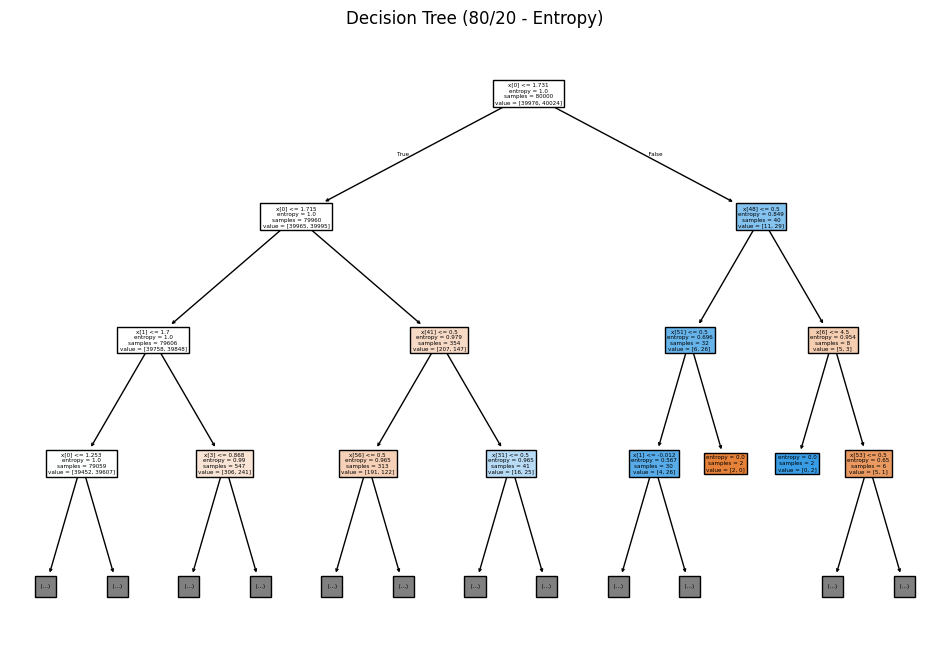

In [24]:
# (80/20) Split - Entropy

model_80_e = DecisionTreeClassifier(criterion='entropy')
model_80_e.fit(X_train_80, y_train_80)

y_pred_80_e = model_80_e.predict(X_test_20)

acc_80_e = accuracy_score(y_test_20, y_pred_80_e)
print("\nAccuracy (80/20 - Entropy):", acc_80_e)

cm_80_e = confusion_matrix(y_test_20, y_pred_80_e)
print("Confusion Matrix (80/20 - Entropy):\n", cm_80_e)

plt.figure(figsize=(12,8))
plot_tree(model_80_e, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Entropy)")
plt.show()



Accuracy (70/30 - Entropy): 0.4982
Confusion Matrix (70/30 - Entropy):
 [[7517 7474]
 [7580 7429]]


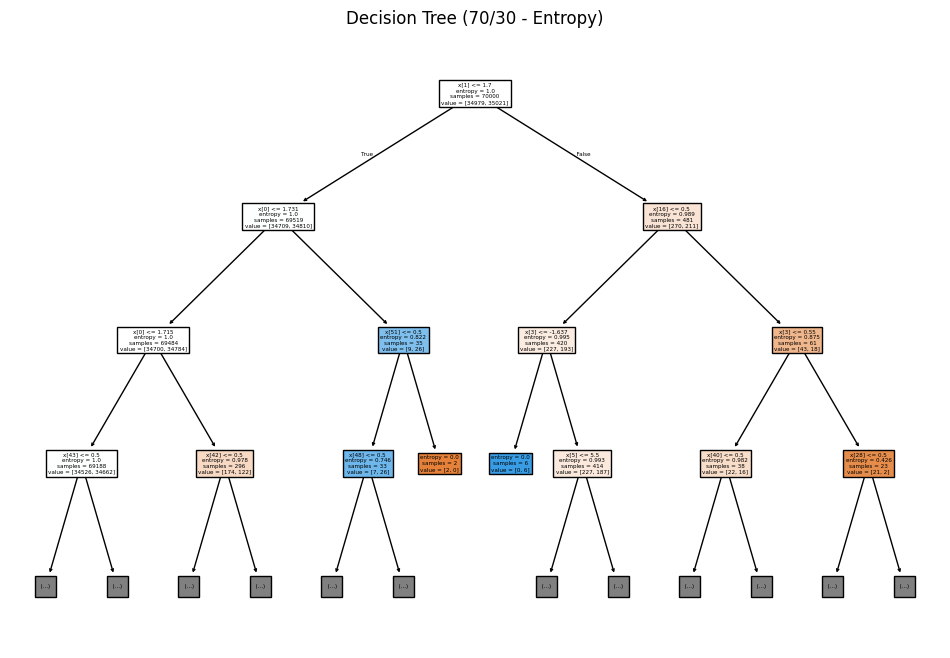

In [25]:

# (70/30) Split - Entropy

model_70_e = DecisionTreeClassifier(criterion='entropy')
model_70_e.fit(X_train_70, y_train_70)

y_pred_70_e = model_70_e.predict(X_test_30)

acc_70_e = accuracy_score(y_test_30, y_pred_70_e)
print("\nAccuracy (70/30 - Entropy):", acc_70_e)

cm_70_e = confusion_matrix(y_test_30, y_pred_70_e)
print("Confusion Matrix (70/30 - Entropy):\n", cm_70_e)

plt.figure(figsize=(12,8))
plot_tree(model_70_e, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Entropy)")
plt.show()

The entropy-based Decision Tree model was evaluated using three train-test splits.

The obtained accuracies were:
- 90/10 split: 0.506
- 80/20 split: 0.49905
- 70/30 split: 0.4982

The results are close across the three partitions, which indicates consistent model performance.

In [26]:
# Reload dataset correctly (for clustering only)
df = pd.read_csv("Cyber Crimes Dataset.csv", sep=';')

In [27]:
data = df.select_dtypes(include=['number']).fillna(df.select_dtypes(include=['number']).mean())
# Keep only numeric columns for clustering
data = df.select_dtypes(include=['number']).fillna(df.select_dtypes(include=['number']).mean())

print(data.shape)
data.head()

(100000, 4)


,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
0,15.31,300,2,164
1,65.05,242,10,64
2,48.99,120,7,87
3,16.29,286,3,23
4,87.66,4,6,129


In [28]:
# Import libraries for clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate WCSS for different K values
wcss = []
K_values = [2, 3, 4]

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

print("WCSS:", wcss)

WCSS: [540516324.5668242, 431416270.38173866, 338393245.47303015]


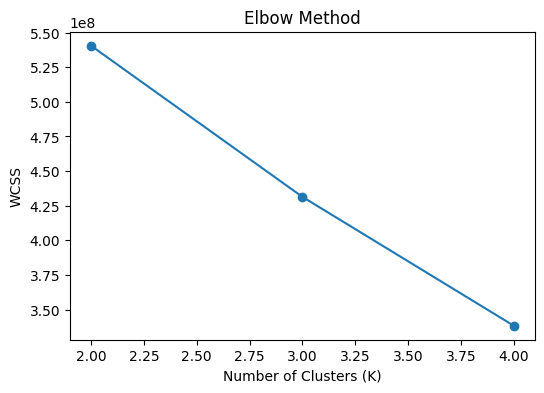

In [29]:
# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [30]:
# Calculate Silhouette Score
# To reduce computation time and avoid performance issues with large datasets,
# we use a representative sample of 10,000 rows instead of the full dataset.
# This approach maintains reliable clustering evaluation while improving efficiency.

sample_data = data.sample(n=10000, random_state=42)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4157
K = 3, Silhouette Score = 0.3458
K = 4, Silhouette Score = 0.3044


In [31]:
# Choose the best K based on Silhouette Score
best_k = 2

# Build final K-Means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit model and get cluster labels
labels = kmeans.fit_predict(data)

print("Final model built with K =", best_k)

Final model built with K = 2


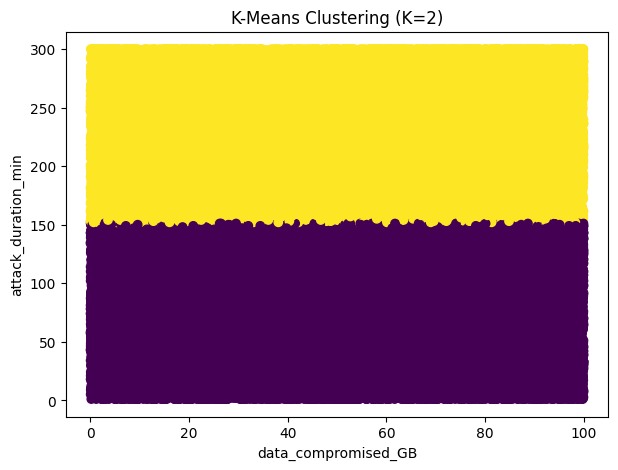

In [32]:
# Visualize clusters using first two features
plt.figure(figsize=(7,5))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels)
plt.title(f"K-Means Clustering (K={best_k})")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.show()

K-Means clustering was applied using three values of K: 2, 3, and 4.

The silhouette scores were:
- K = 2: 0.4157
- K = 3: 0.3458
- K = 4: 0.3044

The best clustering result was obtained at **K = 2**, since it achieved the highest silhouette score.

The elbow method also showed a continuous decrease in WCSS as the number of clusters increased. Based on the evaluation metrics, K = 2 was selected as the optimal number of clusters.

In [33]:
classification_results = pd.DataFrame({
    "Criterion": ["Gini", "Gini", "Gini", "Entropy", "Entropy", "Entropy"],
    "Split": ["90/10", "80/20", "70/30", "90/10", "80/20", "70/30"],
    "Accuracy": [acc_90, acc_80, acc_70, acc_90_e, acc_80_e, acc_70_e]
})

classification_results

,Criterion,Split,Accuracy
0,Gini,90/10,0.503900
1,Gini,80/20,0.499300
2,Gini,70/30,0.497433
3,Entropy,90/10,0.506000
4,Entropy,80/20,0.499050
5,Entropy,70/30,0.498200


In [35]:
clustering_results = pd.DataFrame({
    "K": [2, 3, 4],
    "Silhouette Score": [0.4157, 0.3458, 0.3044],
    "WCSS": wcss
})

clustering_results

,K,Silhouette Score,WCSS
0,2,0.4157,5.405163e+08
1,3,0.3458,4.314163e+08
2,4,0.3044,3.383932e+08


## 6. Results and Discussion

The Decision Tree classifier showed consistent performance across different train-test splits.

For the Gini criterion, the accuracies were close across the three partitions, with the 90/10 split achieving the highest result.

For the entropy criterion, the accuracies were also very similar:
- 90/10: 0.506
- 80/20: 0.49905
- 70/30: 0.4982

This indicates that both Gini and entropy produced stable performance on this dataset, although the results were generally relatively low accuracy, indicating limited predictive performance, which suggests that the current features may have limited predictive power for the target variable.
The clustering results were more meaningful than classification, suggesting that the dataset is better suited for unsupervised learning.

For clustering, the best value of K was **2**, based on the highest silhouette score (0.4157). The elbow plot also supported using a small number of clusters. This suggests that the dataset can be grouped into two main clusters when considering the numerical attributes.
indicating that the data naturally forms two distinct groups based on the selected numerical features.

This suggests that the selected features may not be strongly correlated with the target variable.

## 7. Conclusion

In this project, data mining techniques were applied to analyze cybercrime data using both classification and clustering.

Decision Tree classification was tested using Gini and entropy criteria across three different train-test splits. The results were consistent across the different partitions, but the classification accuracy remained limited.

K-Means clustering was also applied and evaluated using WCSS, the elbow method, and silhouette score. The best clustering result was obtained with K = 2.

Overall, the dataset was suitable for applying both classification and clustering techniques, although classification performance was limited compared to clustering.

##8. References

[1] Scikit-learn Developers, "Scikit-learn: Machine Learning in Python," [Online]. Available: https://scikit-learn.org

[2] J. Han, M. Kamber, and J. Pei, Data Mining: Concepts and Techniques, 3rd ed. Morgan Kaufmann, 2011.

[3] Kaggle, "Cyber Crimes Dataset," [Online]. Available: https://www.kaggle.com/